<a href="https://colab.research.google.com/github/iamviplavkr/viplav_kumar_23FE10CSE00421_ML/blob/main/LAB_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving student_por.csv to student_por.csv


In [2]:
!pip install nltk wordcloud

In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [5]:
df = pd.read_csv("student_por.csv")

print(df.head())
print(df.columns)

  school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0  GP;"F";18;"U";"GT3";"A";4;4;"at_home";"teacher...                                                                                                                                                                                 
1  GP;"F";17;"U";"GT3";"T";1;1;"at_home";"other";...                                                                                                                                                                                 
2  GP;"F";15;"U";"LE3";"T";1;1;"at_home";"other";...                                                                                                                                                                                 
3  GP;"F";15;"U";"GT3";"T";4;2;"health";"services...                            

In [6]:
text_column = "POR"   # change if needed

In [10]:
print(df.columns)

Index(['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3'], dtype='object')


In [11]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3'], dtype='object')


In [12]:
text_column = "Description"

In [14]:
print(df.columns.tolist())

['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']


In [15]:
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [16]:
for col in df.columns:
    print(col, "->", df[col].dtype)

school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3 -> object


In [17]:
text_column = df.select_dtypes(include=['object']).columns[0]
print("Using column:", text_column)

Using column: school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3


In [18]:
print(df[text_column].head())

0    GP;"F";18;"U";"GT3";"A";4;4;"at_home";"teacher...
1    GP;"F";17;"U";"GT3";"T";1;1;"at_home";"other";...
2    GP;"F";15;"U";"LE3";"T";1;1;"at_home";"other";...
3    GP;"F";15;"U";"GT3";"T";4;2;"health";"services...
4    GP;"F";16;"U";"GT3";"T";3;3;"other";"other";"h...
Name: school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3, dtype: object


In [20]:
df = pd.read_csv("student_por.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Auto detect text column
text_column = df.select_dtypes(include=['object']).columns[0]

print("Using column:", text_column)
print(df[text_column].head())

Using column: school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0    GP;"F";18;"U";"GT3";"A";4;4;"at_home";"teacher...
1    GP;"F";17;"U";"GT3";"T";1;1;"at_home";"other";...
2    GP;"F";15;"U";"LE3";"T";1;1;"at_home";"other";...
3    GP;"F";15;"U";"GT3";"T";4;2;"health";"services...
4    GP;"F";16;"U";"GT3";"T";3;3;"other";"other";"h...
Name: school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3, dtype: object


In [21]:
print(df.columns.tolist())

['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']


In [22]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["clean_text"] = df[text_column].apply(clean_text)

df[["clean_text"]].head()

,clean_text
0,gpfugtaathometeachercoursemotheryesnononoyesye...
1,gpfugttathomeothercoursefathernoyesnononoyesyesno
2,gpfuletathomeotherothermotheryesnononoyesyesyesno
3,gpfugtthealthserviceshomemothernoyesnoyesyesye...
4,gpfugttotherotherhomefathernoyesnonoyesyesnono


In [24]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [25]:
df["tokens"] = df["clean_text"].apply(tokenize)

In [26]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize(words):
    return [lemmatizer.lemmatize(w) for w in words]

df["lemmas"] = df["tokens"].apply(lemmatize)

df[["tokens", "lemmas"]].head()

,tokens,lemmas
0,[gpfugtaathometeachercoursemotheryesnononoyesy...,[gpfugtaathometeachercoursemotheryesnononoyesy...
1,[gpfugttathomeothercoursefathernoyesnononoyesy...,[gpfugttathomeothercoursefathernoyesnononoyesy...
2,[gpfuletathomeotherothermotheryesnononoyesyesy...,[gpfuletathomeotherothermotheryesnononoyesyesy...
3,[gpfugtthealthserviceshomemothernoyesnoyesyesy...,[gpfugtthealthserviceshomemothernoyesnoyesyesy...
4,[gpfugttotherotherhomefathernoyesnonoyesyesnono],[gpfugttotherotherhomefathernoyesnonoyesyesnono]


In [27]:
df["processed_text"] = df["lemmas"].apply(lambda x: " ".join(x))

df[["processed_text"]].head()

,processed_text
0,gpfugtaathometeachercoursemotheryesnononoyesye...
1,gpfugttathomeothercoursefathernoyesnononoyesyesno
2,gpfuletathomeotherothermotheryesnononoyesyesyesno
3,gpfugtthealthserviceshomemothernoyesnoyesyesye...
4,gpfugttotherotherhomefathernoyesnonoyesyesnono


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)

X = vectorizer.fit_transform(df["processed_text"])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (649, 622)


In [29]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['gpfrgtaotherotherhomemothernoyesnonoyesyesyesno'
 'gpfrgtaotherserviceshomemothernonononononoyesyes'
 'gpfrgttathomeothercoursefathernoyesnonoyesyesyesyes'
 'gpfrgttathomeothercoursemothernononoyesyesyesnono'
 'gpfrgttathomeothercoursemothernoyesnonoyesyesnono'
 'gpfrgttathomeothercoursemothernoyesnoyesnoyesnono'
 'gpfrgttathomeotherhomemotheryesyesyesyesyesyesyesno'
 'gpfrgttathomeotherreputationmotheryesyesnoyesyesyesnono'
 'gpfrgttathomeservicescoursefathernoyesnoyesnoyesyesno'
 'gpfrgttathomeservicescoursemothernononoyesyesyesnono'
 'gpfrgttathomeservicesreputationmothernoyesnoyesyesyesyesno'
 'gpfrgtthealthteacherothermothernoyesnoyesyesyesnono'
 'gpfrgttotherothercoursemothernononoyesyesyesyesyes'
 'gpfrgttotherothercoursemothernoyesnoyesyesyesyesno'
 'gpfrgttotherothercourseothernoyesyesyesyesnoyesyes'
 'gpfrgttotherotherhomemotheryesnononoyesyesnono'
 'gpfrgttotherotherreputationmothernononoyesyesyesyesyes'
 'gpfrgttotherotherreputationmothernoyesnonoyesnoyesyes'
 'gpfrgttoth

In [30]:
from collections import Counter

all_words = " ".join(df["processed_text"]).split()
word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('gpfugttotherotherhomemothernoyesnonoyesyesyesyes', 3), ('gpfugttotherothercoursemothernoyesnoyesyesyesyesyes', 3), ('msfrgttathomeothercoursemothernoyesnonoyesyesyesno', 3), ('gpfugttservicesservicesreputationmothernoyesnoyesyesyesyesno', 2), ('gpfugttotherotherreputationmotheryesyesnoyesyesyesnono', 2), ('gpmuletteacherothercoursemothernononoyesyesyesyesno', 2), ('gpfrgttserviceshealthcoursemotheryesyesnoyesyesyesyesno', 2), ('gpmugttotherotherhomemothernoyesnonoyesyesyesno', 2), ('gpmugttotherothercoursemothernonononoyesyesyesno', 2), ('gpfugttotherotherreputationmothernonononoyesyesyesyes', 2), ('gpfugttathomeothercoursemothernoyesnonoyesyesyesno', 2), ('gpfugttotherothercoursemothernoyesnonoyesyesnoyes', 2), ('gpmrgttotherothercoursefathernoyesnoyesyesyesyesno', 2), ('gpfugttotherotherhomemothernonononoyesyesyesyes', 2), ('gpfugttteacherservicescoursemothernoyesnoyesyesyesyesno', 2), ('gpfugttotherotherreputationmothernoyesnonoyesyesyesno', 2), ('gpmugttservicesservicesothermoth

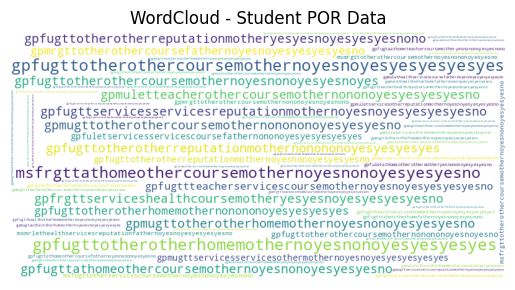

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["processed_text"])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud - Student POR Data")
plt.show()